In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.pyplot import subplot_mosaic
import os
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import mannwhitneyu, false_discovery_control
import re
from itertools import combinations
from scipy.stats import pearsonr, fisher_exact
import ast

In [2]:
def stack_triangle(df, col):
    df = pd.DataFrame(
        df.where(
            np.tri(
                df.shape[0],
                dtype=bool,
                k=-1
            ),
            np.nan
        ).stack(dropna=True), columns=[col] 
    )
    
    return df


In [3]:
# Function that generates and saves the ROC curve
def generate_roc_curve(
    data,
    target_col,
    feature_col,
):
    # ROC curve using all gene pairs
    fpr, tpr, thr = roc_curve(data[target_col], data[feature_col])
    auroc = roc_auc_score(data[target_col], data[feature_col])
    
    return fpr, tpr, thr, auroc

In [4]:
def fig_to_panels(fig, axes, output_dir):
    # Save individual panels of a figure 
    
    for panel_name, ax in axes.items():
        # Extract the panel title
        panel_title = ax.get_title()

        # Sanitize the panel title to use in filenames
        safe_title = panel_title.replace(" ", "_").replace("/", "_").replace("\n", "_").lower()

        # Create the filename for the current panel
        output_file = os.path.join(output_dir,safe_title)

        # Adjust the bounding box to include everything (labels, titles, etc.)
        extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

        # Save the individual panel using the adjusted bounding box
        fig.savefig(output_file + '.pdf', bbox_inches=extent, dpi=300)
        fig.savefig(output_file + '.png', bbox_inches=extent)

        print(f"Saved panel '{panel_title}' to {output_file}")


In [5]:
def network_to_adj(network_path):
    network = pd.read_csv(
        network_path,
        usecols=['complex1', 'complex2', 'adj']
    )

    # Add a mirrored version of the network to make it symmetric
    network_mirrored = network.copy()
    network_mirrored.columns = ['complex2', 'complex1', 'adj']
    network = pd.concat([network, network_mirrored], ignore_index=True)

    adj = network.pivot(index='complex1', columns='complex2', values='adj').fillna(0)
    return adj

In [6]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

# Compare

In [7]:
df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/compare_results.csv', index_col=0)
df = df.drop(columns=['avg_coev_tom_correlation'])
#df = df[df.index != 'testis']
df['interactions_mannwhitneyu_p_adj'] = false_discovery_control(df['interactions_mannwhitneyu_p'], method='bh')

In [8]:
auroc_a = df['interactions_auroc']
auroc_t = df.query('condition == "tumor"')['interactions_auroc']
auroc_n = df.query('condition == "normal"')['interactions_auroc']

print('AUROC')

print('All tissues:', auroc_a.mean(), '+/-', np.std(auroc_a))
print('Normal', auroc_n.mean(), '+/-', np.std(auroc_n))
print('Tumor', auroc_t.mean(), '+/-', np.std(auroc_t))

ua = df['interactions_mannwhitneyu_U']
ut = df.query('condition == "tumor"')['interactions_mannwhitneyu_U']
un = df.query('condition == "normal"')['interactions_mannwhitneyu_U']

AUROC
All tissues: 0.6165693346411175 +/- 0.03869659366368164
Normal 0.5913339627313167 +/- 0.020279851115496902
Tumor 0.6528451817614561 +/- 0.028764581664141135


In [9]:
df['-log10_mannwhitneyu_p_adj'] = -np.log10(df['interactions_mannwhitneyu_p_adj'])

In [10]:
df.drop(columns='interactions_mannwhitneyu_p', inplace=True)
df.drop(columns='interactions_mannwhitneyu_p_adj', inplace=True)

In [11]:
same_module_df = df[['condition', 'n_interactions_same_module', 'tot_interactions']].copy()

In [12]:
t_tot_ints = same_module_df.query('condition == "tumor"')['tot_interactions'].sum()
n_tot_ints = same_module_df.query('condition == "normal"')['tot_interactions'].sum()

t_same_ints = same_module_df.query('condition == "tumor"')['n_interactions_same_module'].sum()
n_same_ints = same_module_df.query('condition == "normal"')['n_interactions_same_module'].sum()

table = [
    [t_same_ints, t_tot_ints-t_same_ints],
    [n_same_ints, n_tot_ints-n_same_ints]
]

/var/tmp/pbs.436024.pbs01/ipykernel_279728/198129669.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=fs)


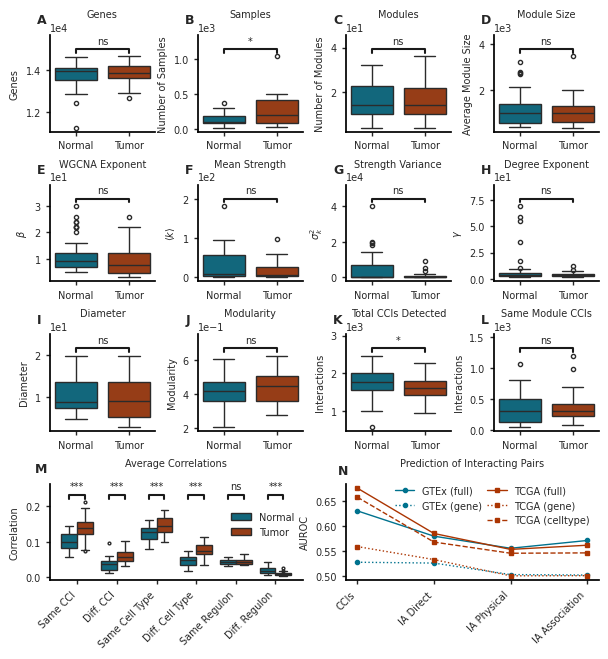

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

sns.set(style="whitegrid")

fs = 7

# -----------------------------
# Plot metadata
# -----------------------------
title_dict = {
    'n_genes': 'Genes',
    'n_samples': 'Samples',
    'n_modules': 'Modules',
    'avg_module_size': 'Module Size',
    'sft_power': 'WGCNA Exponent',
    'avg_degree': 'Mean Strength',
    'var_degree': 'Strength Variance',
    'powerlaw_alpha': 'Degree Exponent',
    'diameter': 'Diameter',
    #'clustering_global': 'Clustering Coefficient',
    'modularity': 'Modularity',
    'tot_interactions': 'Total CCIs Detected',
    'n_interactions_same_module': 'Same Module CCIs',
}

ylabel_dict = {
    'n_genes': 'Genes',
    'n_samples': 'Number of Samples',
    'n_modules': 'Number of Modules',
    'avg_module_size': 'Average Module Size',
    'sft_power': '$ \\beta $',
    'avg_degree': '$ \\langle k \\rangle $',
    'var_degree': '$ \\sigma^2_{k}$',
    'powerlaw_alpha': '$\\gamma$',
    'diameter': 'Diameter',
    #'clustering_global': 'Clustering coefficient',
    'modularity': 'Modularity',
    'tot_interactions': 'Interactions',
    'n_interactions_same_module': 'Interactions',
}

columns = list(title_dict.keys())

# -----------------------------
# Stats
# -----------------------------
def compute_p_value(data, column):
    normal_data = data[data['condition'] == 'normal'][column]
    tumor_data = data[data['condition'] == 'tumor'][column]
    _, p_value = mannwhitneyu(normal_data, tumor_data, alternative='two-sided')
    return p_value


def add_significance(ax, data, column, p_value):

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    normal_data = data[data['condition'] == 'normal'][column]
    tumor_data = data[data['condition'] == 'tumor'][column]

    y_max = max(normal_data.max(), tumor_data.max())
    y_min = min(normal_data.min(), tumor_data.min())

    h = 0.05 * (y_max - y_min if y_max > y_min else 1)

    y_bar_start = y_max + h
    y_bar_end = y_max + 2*h

    ax.plot([0,0,1,1],[y_bar_start,y_bar_end,y_bar_end,y_bar_start],lw=1.5,c='k')
    ax.text(0.5, y_bar_end + h, significance, ha='center', va='bottom', fontsize=fs)

    ax.set_ylim(top=y_bar_end + h*4)


# -----------------------------
# Compute p-values
# -----------------------------
pvals = {c: compute_p_value(df, c) for c in columns}


# -----------------------------
# Mosaic layout
# -----------------------------
mosaic = """
abcd
efgh
ijkl
mmnn
"""

inch_to_mm = 1 / 25.4

fig, axd = plt.subplot_mosaic(mosaic, figsize=(7.08, 7.08))
plt.subplots_adjust(
    wspace=0.41,
    hspace=0.55,
)

panel_keys = list("abcdefghijklm")

# -----------------------------
# Boxplots
# -----------------------------
for key, col in zip(panel_keys, columns):

    ax = axd[key]

    sns.boxplot(
        x='condition',
        y=col,
        hue='condition',
        data=df,
        palette=[ncolor, tcolor],
        ax=ax,
        fliersize=3,
    )

    ax.set_title(title_dict[col], fontsize=fs, y=1.10)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel_dict[col], fontsize=fs)

    ax.set_xticks([0,1])
    ax.set_xticklabels(['Normal','Tumor'], fontsize=fs)

    ax.tick_params(axis='both', labelsize=fs)

    add_significance(ax, df, col, pvals[col])

    ax.text(-0.12,1.12,key.upper(),
            fontsize=fs+2, fontweight='bold',
            transform=ax.transAxes)

    ax.grid(False)
    ax.spines[['right','top']].set_visible(False)

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
    
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=None)
    ax.yaxis.get_offset_text().set_fontsize(fs)

    ax.tick_params(axis='both', which='both', direction='out',
               length=3, width=1,
               bottom=True, top=False, left=True, right=False)
    
# -----------------------------
# SAME/DIFF CT/REGULON (N)
# -----------------------------
ax = axd['m']

df2 = pd.read_csv('/home/lnemati/pathway_crosstalk/results/comparison/averages.csv')
df2 = df2.query('value_type == "average_corr"')

df2['interaction_type'] = df2.interaction_type.replace({ 
    'ccc_lr_pairs.csv': 'Same CCI',
    'mismatched_lr_pairs.csv': 'Diff. CCI',
    'same_regulon.csv': 'Same Regulon',
    'different_regulon.csv': 'Diff. Regulon',
    'same_cell_type.csv': 'Same Cell Type',
    'different_cell_type.csv': 'Diff. Cell Type'
})

pairs = {
    'CCIs': ['Same CCI', 'Diff. CCI'],
    'Cell Type Markers': ['Same Cell Type', 'Diff. Cell Type'],
    'Regulons': ['Same Regulon', 'Diff. Regulon']
}

# ---- reshape into long format for seaborn ----
rows = []
for group, labels in pairs.items():
    sub = df2[df2['interaction_type'].isin(labels)].copy()
    sub['group'] = group
    rows.append(sub)

plot_df = pd.concat(rows)

# preserve ordering
plot_df['interaction_type'] = pd.Categorical(
    plot_df['interaction_type'],
    categories=[
        'Same CCI','Diff. CCI',
        'Same Cell Type','Diff. Cell Type',
        'Same Regulon','Diff. Regulon'
    ],
    ordered=True
)

# ---- seaborn boxplot ----
sns.boxplot(
    x='interaction_type',
    y='value',
    hue='condition',
    data=plot_df,
    palette=[ncolor, tcolor],
    ax=ax,
    fliersize=2,
    linewidth=1
)

# ---- compute GLOBAL y range across all categories ----
global_y_max = plot_df['value'].max()
global_y_min = plot_df['value'].min()

h = 0.05 * (global_y_max - global_y_min if global_y_max > global_y_min else 1)

y_bar_start = global_y_max + h
y_bar_end = global_y_max + 2*h
text_y = y_bar_end + h

# ---- compute GLOBAL y range across all categories ----
global_y_max = plot_df['value'].max()
global_y_min = plot_df['value'].min()

h = 0.05 * (global_y_max - global_y_min if global_y_max > global_y_min else 1)

y_bar_start = global_y_max + h
y_bar_end = global_y_max + 2*h
text_y = y_bar_end + h

# ---- compute ALL p-values first ----
cats = plot_df['interaction_type'].cat.categories
raw_pvals = []

for cat in cats:
    sub = plot_df[plot_df['interaction_type'] == cat]

    normal_data = sub[sub['condition'] == 'normal']['value']
    tumor_data = sub[sub['condition'] == 'tumor']['value']

    if len(normal_data) == 0 or len(tumor_data) == 0:
        raw_pvals.append(np.nan)
        continue

    _, p = mannwhitneyu(normal_data, tumor_data, alternative='two-sided')
    raw_pvals.append(p)

# ---- apply FDR correction ----
pvals_corrected = false_discovery_control(raw_pvals)

# ---- plot with corrected p-values ----
for i, (cat, p_value) in enumerate(zip(cats, pvals_corrected)):

    if np.isnan(p_value):
        continue

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    ax.plot([i-0.2, i-0.2, i+0.2, i+0.2],
            [y_bar_start, y_bar_end, y_bar_end, y_bar_start],
            lw=1.5, c='k')

    ax.text(i, text_y, significance,
            ha='center', va='bottom', fontsize=fs)

# ---- expand ylim once ----
ax.set_ylim(top=text_y + h*2)

# ---- styling to match figure ----
ax.set_title("Average Correlations", fontsize=fs, y=1.10)
ax.set_xlabel("")
ax.set_ylabel("Correlation", fontsize=fs)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=fs)
ax.tick_params(axis='both', labelsize=fs)

ax.text(-0.06,1.12,"M",
        fontsize=fs+2, fontweight='bold',
        transform=ax.transAxes)

ax.grid(False)
ax.spines[['right','top']].set_visible(False)

for spine in ax.spines.values():
    spine.set_edgecolor('black')

# optional: cleaner legend (like others)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ['Normal','Tumor'],
          frameon=False, fontsize=fs, loc='upper right', bbox_to_anchor=(1, 0.8))

ax.tick_params(axis='both', which='both', direction='out',
               length=3, width=1,
               bottom=True, top=False, left=True, right=False)

# -----------------------------
# AUROC (N)
# -----------------------------
pcorr_results = pd.read_csv(
"/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/aurocs_ccis_intact.csv",
index_col=0
)

ax = axd['n']

file_order = ["ccc_lr_pairs","intact_direct","intact_physical","intact_association"]

pcorr_results["interaction_file"] = pd.Categorical(
    pcorr_results["interaction_file"],
    categories=file_order,
    ordered=True
)

# Genes Regressed partial correlation
ct_regressed = pd.read_csv("/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/celltypes/aurocs_ccis_intact.csv", index_col=0)
ct_regressed = ct_regressed.query('type == "pcorr"')
ct_regressed = ct_regressed.rename(columns={'U': 'mannwhitney_U', 'p': 'mannwhitney_p'})
ct_regressed['type'] = ct_regressed['type'].replace({'pcorr': 'pcorr_ct'})
ct_regressed['dataset'] = 'tcga'
pcorr_results = pd.concat([pcorr_results, ct_regressed])

colors = {"tcga":"#ab3502ff","gtex":"#00728eff"}
markers = {"tcga":"s","gtex":"o"}
linestyles = {"corr":"solid", "pcorr":"dotted", "pcorr_ct":"dashed"}

for dataset in pcorr_results["dataset"].unique():

    for corr_type in ["corr", "pcorr", "pcorr_ct"]:

        subset = pcorr_results[
            (pcorr_results.dataset==dataset) &
            (pcorr_results.type==corr_type)
        ]
        
        if subset.empty:
            continue

        dataset_label = dataset.replace('tcga','TCGA').replace('gtex','GTEx')
        corr_label = corr_type.replace('pcorr_ct','(celltype)').replace('pcorr','(gene)').replace('corr','(full)')

        ax.plot(
            subset["interaction_file"],
            subset["auroc"],
            marker=markers[dataset],
            linestyle=linestyles[corr_type],
            color=colors[dataset],
            linewidth=1,
            markersize=3,
            label=f"{dataset_label} {corr_label}"
        )

ax.set_title("Prediction of Interacting Pairs", fontsize=fs, y=1.10)
ax.set_ylabel("AUROC", fontsize=fs)

ax.set_xticks(range(len(file_order)))
ax.set_xticklabels(['CCIs','IA Direct','IA Physical','IA Association'], rotation=45, ha='right', fontsize=fs)

ax.tick_params(axis='both', labelsize=fs)

ax.text(-0.03,1.1,"N",fontsize=fs+2,fontweight='bold',transform=ax.transAxes)

ax.grid(False)
ax.spines[['right','top']].set_visible(False)

for spine in ax.spines.values():
    spine.set_edgecolor('black')

ax.tick_params(axis='both', which='both', direction='out',
               length=3, width=1,
               bottom=True, top=False, left=True, right=False)

# Legend 

from matplotlib.lines import Line2D

handles, labels = ax.get_legend_handles_labels()

gtex_idx = [i for i, l in enumerate(labels) if "GTEx" in l]
tcga_idx = [i for i, l in enumerate(labels) if "TCGA" in l]

dummy = Line2D([], [], linestyle='none', label="")

order = [
    gtex_idx[0], gtex_idx[1], dummy, 
    tcga_idx[0], tcga_idx[1], tcga_idx[2],
]

new_handles = []
new_labels = []

for i in order:
    if isinstance(i, Line2D):
        new_handles.append(i)
        new_labels.append("")
    else:
        new_handles.append(handles[i])
        new_labels.append(labels[i])

ax.legend(
    new_handles,
    new_labels,
    ncol=2,
    frameon=False,
    fontsize=fs,
    columnspacing=0.5,
    loc="upper right",
    bbox_to_anchor=(1, 1.07)
)

# -----------------------------
# Save
# -----------------------------
name = 'S1'
figures_dir = '/home/lnemati/pathway_crosstalk/results/figures/new_figures'
os.makedirs(os.path.join(figures_dir, name), exist_ok=True)

#plt.savefig(os.path.join(figures_dir, name, name) + '.pdf', bbox_inches='tight', dpi=300)
#plt.savefig(os.path.join(figures_dir, name, name) + '.png', bbox_inches='tight', dpi=300)

plt.show()

In [14]:
raw_pvals

[np.float64(1.4646719425359444e-07),
 np.float64(8.578663964030806e-07),
 np.float64(0.00013648080387516345),
 np.float64(9.333730240262322e-10),
 np.float64(0.12630617757580262),
 np.float64(1.5477400937852316e-07)]

In [15]:
pvals_corrected

array([3.09548019e-07, 1.28679959e-06, 1.63776965e-04, 5.60023814e-09,
       1.26306178e-01, 3.09548019e-07])

In [16]:
# !!!!! REMOVED CLUSTERING COEFFICIENT !!!!!!!!!!

In [17]:
a = df2.query('condition == "tumor" and interaction_type == "Same CCI"')['value']
b = df2.query('condition == "tumor" and interaction_type == "Same Cell Type"')['value']

In [18]:
mannwhitneyu(a, b)

MannwhitneyuResult(statistic=np.float64(411.0), pvalue=np.float64(0.17719922222532425))

In [19]:
a.median()

np.float64(0.1391731321099433)

In [20]:
b.median()

np.float64(0.1449930658573772)